## Extended Linear Regression on Polynoms of second and third degrees

### 1 Многочлен первой степени (прямая)

#### 1.1 Вводим необходимые библиотеки и создаем набор данных (зашумленный многочлен первой степени)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

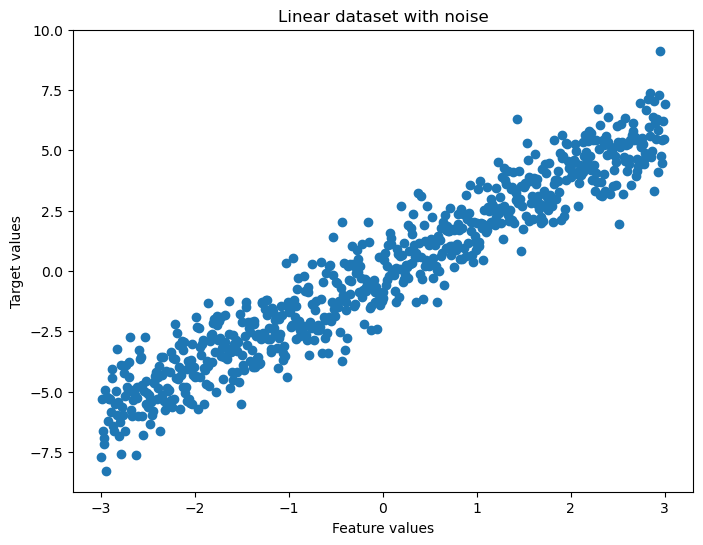

In [2]:
X = np.linspace(-3, 3, 700).reshape(700, 1)
y = X * 2 + np.random.randn(700).reshape(700, 1)

plt.figure(figsize=(8,6))
plt.scatter(X, y)
plt.title("Linear dataset with noise")
plt.xlabel("Feature values")
plt.ylabel("Target values")
plt.show()

#### 1.2 Разделяем данные на тренировочные и тестовые

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((525, 1), (525, 1), (175, 1), (175, 1))

### 1.3 Определяем класс Линейная регрессия и два метода: аналитический и градиентный спуск

In [4]:
class LinRegres:
    def init(model):
        pass

    def traingraddescent(model, X, y, rate_iter = 0.01, count_iter = 700):
        model.weights, model.bias = (np.zeros(X.shape[1])), 0
        costs = []
        
        for i in range(count_iter):
            costs.append(model.funcloss(X, y))
            if i % 100 == 0: 
                print(f"Cost at iteration {i}: {costs[-1]}")
                
            dJ_dw = (2/X.shape[0]) * np.dot(X.T, model.predict(X) - y)
            dJ_db = (2/X.shape[0]) * np.sum(model.predict(X) - y)
            model.weights = model.weights - rate_iter * dJ_dw
            model.bias = model.bias - rate_iter * dJ_db
            
        return model.weights, model.bias, costs

    def analytparam (model, X, y):
        X = np.hstack((X,np.ones([X.shape[0],1])))
        model.weights = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
        model.bias = np.array(model.weights[-1])
        model.weights = np.array(model.weights[0:-1])
        return model.weights, model.bias

    def predict(model, X):
        return np.vstack(np.dot(X, model.weights) + model.bias)

    def funcloss(model, X, y):
        return (np.sum((model.predict(X) - y)**2))/(X.shape[0])

#### 1.4 Обучаем модель аналитическим методом

In [5]:
line = LinRegres()
param = line.analytparam(X_train, y_train)
param

(array([[1.97587378]]), array([-0.02033128]))

#### 1.4.1 Значения функции потерь на тренировочном и тестовом наборах

In [6]:
line.funcloss(X_train, y_train), line.funcloss(X_test, y_test)

(np.float64(1.044312734505126), np.float64(1.0334662144187843))

#### 1.4.2 Визуализация построенной модели на наборе данных

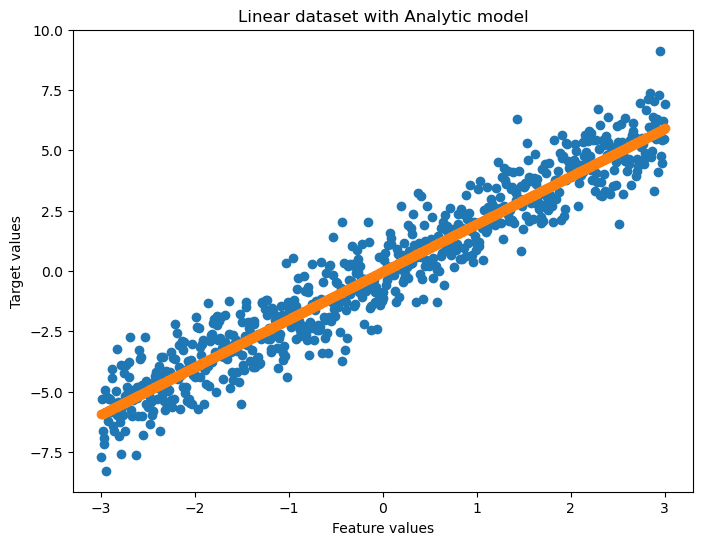

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X, y)
plt.scatter(X, line.predict(X))
plt.title("Linear dataset with Analytic model")
plt.xlabel("Feature values")
plt.ylabel("Target values")
plt.show()

#### 1.5 Обучаем модель методом Градиентного спуска

Cost at iteration 0: 12.775760298590907
Cost at iteration 100: 1.044312734505126
Cost at iteration 200: 1.044312734505126
Cost at iteration 300: 1.044312734505126
Cost at iteration 400: 1.044312734505126
Cost at iteration 500: 1.044312734505126
Cost at iteration 600: 1.044312734505126


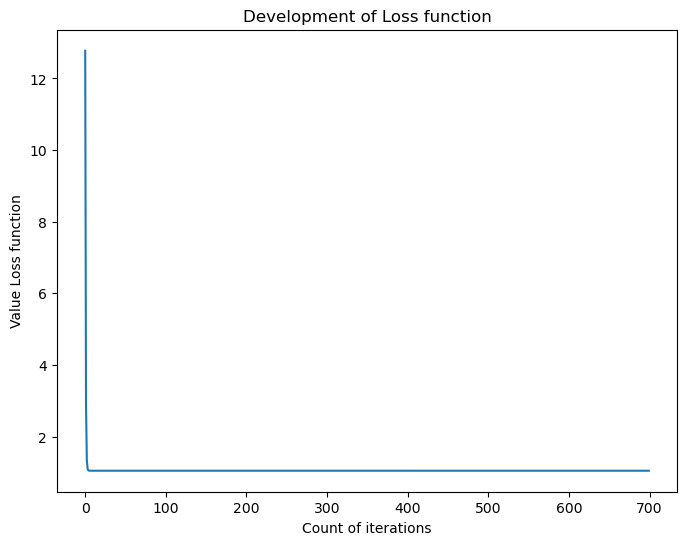

In [8]:
linegrad = LinRegres()
param, bias, lincosts = linegrad.traingraddescent(X_train, y_train, 0.1, 700)

fig = plt.figure(figsize=(8,6))
plt.plot(np.arange(700), lincosts)
plt.title("Development of Loss function")
plt.xlabel("Count of iterations")
plt.ylabel("Value Loss function")
plt.show()

#### 1.5.1 Значения функции потерь на тренировочном и тестовом наборах

In [9]:
param, bias

(array([[1.97587378]]), np.float64(-0.020331278311223003))

In [10]:
linegrad.funcloss(X_train, y_train), linegrad.funcloss(X_test, y_test)

(np.float64(1.044312734505126), np.float64(1.0334662144187845))

#### 1.5.1 Визуализация построенной модели на наборе данных

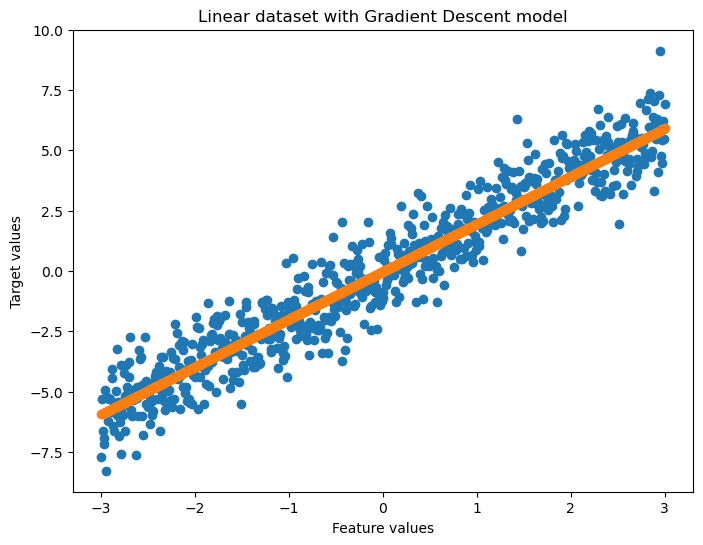

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(X, y)
plt.scatter(X, linegrad.predict(X))
plt.title("Linear dataset with Gradient Descent model")
plt.xlabel("Feature values")
plt.ylabel("Target values")
plt.show()

### 2. Многочлен второй степени (парабола)

#### 2.1 Создаем набор данных (зашумленный многочлен второй степени)

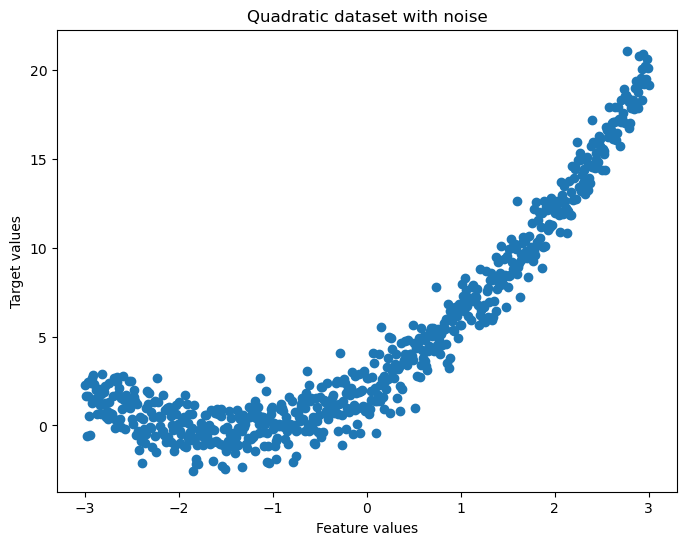

In [12]:
Xn = np.linspace(-3, 3, 700).reshape(700, 1)
yn = Xn ** 2 + Xn * 3 + 2 + np.random.randn(700).reshape(700, 1)

plt.figure(figsize=(8,6))
plt.scatter(Xn, yn)
plt.title("Quadratic dataset with noise")
plt.xlabel("Feature values")
plt.ylabel("Target values")
plt.show()

#### 2.2 Делим датасет на тренировочный и тестовый выборки

In [13]:
Xn_train, Xn_test, yn_train, yn_test = train_test_split(Xn, yn)
Xn_train.shape, Xn_test.shape, yn_train.shape, yn_test.shape

((525, 1), (175, 1), (525, 1), (175, 1))

### 2.3 Определяем класс Квадратичная регрессия и два метода: аналитический и градиентный спуск

In [14]:
class QuadRegres:
    def init(model):
        pass

    def traingraddescent(model, X, y, rate_iter = 0.01, count_iter = 700):
        model.weights = (np.zeros(3))
        costs = []
        
        for i in range(count_iter):
            costs.append(model.funcloss(X, y))
            if i % 100 == 0: 
                print(f"Cost at iteration {i}: {costs[-1]}")
                
            dJ_dw0 = (2/X.shape[0]) * np.sum(model.predict(X) - y)
            dJ_dw1 = (2/X.shape[0]) * np.dot(X.T, model.predict(X) - y)
            dJ_dw2 = (2/X.shape[0]) * np.dot((X ** 2).T, model.predict(X) - y)
            model.weights[0] = model.weights[0] - rate_iter * dJ_dw0
            model.weights[1] = model.weights[1] - rate_iter * dJ_dw1
            model.weights[2] = model.weights[2] - rate_iter * dJ_dw2
            
        return model.weights, costs

    def analytparam (model, X, y):
        X_f = np.hstack((np.ones([X.shape[0], 1]), X, X ** 2))
        model.weights = np.dot(np.dot(np.linalg.inv(np.dot(X_f.T, X_f)), X_f.T), y)
        return model.weights

    def predict(model, X):
        X_f = np.hstack((np.ones([X.shape[0], 1]), X, X ** 2))
        return np.vstack(np.dot(X_f, model.weights))

    def funcloss(model, X, y):
        return (np.sum((model.predict(X) - y)**2))/(X.shape[0])

#### 2.4 Обучаем квадратичную модель аналитическим методом

In [15]:
parabola = QuadRegres()
quadweightsanal = parabola.analytparam(Xn_train, yn_train)
quadweightsanal

array([[2.09094882],
       [3.03277185],
       [0.97627214]])

#### 2.4.1 Значения функции потерь на тренировочном и тестовом выборках

In [16]:
parabola.funcloss(Xn_train, yn_train), parabola.funcloss(Xn_test, yn_test)

(np.float64(0.9554411902329427), np.float64(1.068732313101804))

#### 2.4.2 Визуализация построенной квадратичной модели аналитическим путём

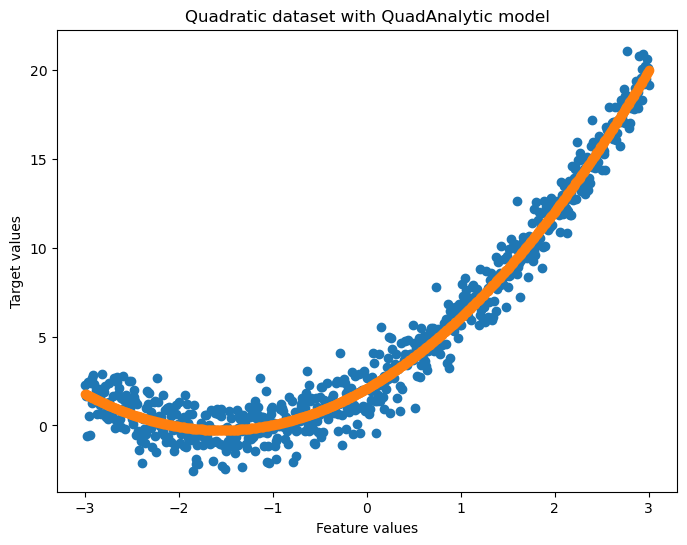

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(Xn, yn)
plt.scatter(Xn, parabola.predict(Xn))
plt.title("Quadratic dataset with QuadAnalytic model")
plt.xlabel("Feature values")
plt.ylabel("Target values")
plt.show()

#### 2.5 Обучаем квадратичную модель методом Градиентного спуска

Cost at iteration 0: 61.67412968449468


C:\Users\Богдан\AppData\Local\Temp\ipykernel_3280\3952146095.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  model.weights[1] = model.weights[1] - rate_iter * dJ_dw1
C:\Users\Богдан\AppData\Local\Temp\ipykernel_3280\3952146095.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  model.weights[2] = model.weights[2] - rate_iter * dJ_dw2


Cost at iteration 100: 1.225325468191798
Cost at iteration 200: 1.0043156960341935
Cost at iteration 300: 0.9642951137665841
Cost at iteration 400: 0.957045134071116
Cost at iteration 500: 0.9557317547297152
Cost at iteration 600: 0.955493827815865


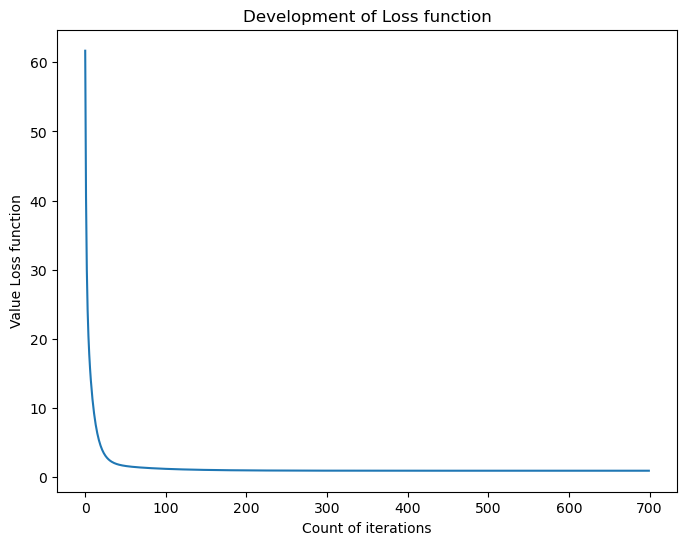

In [18]:
parabgrad = QuadRegres()
quadweightsgrad, quadcosts = parabgrad.traingraddescent(Xn_train, yn_train)
quadweightsgrad

fig = plt.figure(figsize=(8,6))
plt.plot(np.arange(700), quadcosts)
plt.title("Development of Loss function")
plt.xlabel("Count of iterations")
plt.ylabel("Value Loss function")
plt.show()

#### 2.5.1 Значения функции потерь на тренировочной и тестовой выборках

In [19]:
parabgrad.funcloss(Xn_train, yn_train), parabgrad.funcloss(Xn_test, yn_test)

(np.float64(0.9554507258615783), np.float64(1.068059714764202))

#### 2.5.2 Визуализация построенной квадратичной модели методом Градиентного спуска

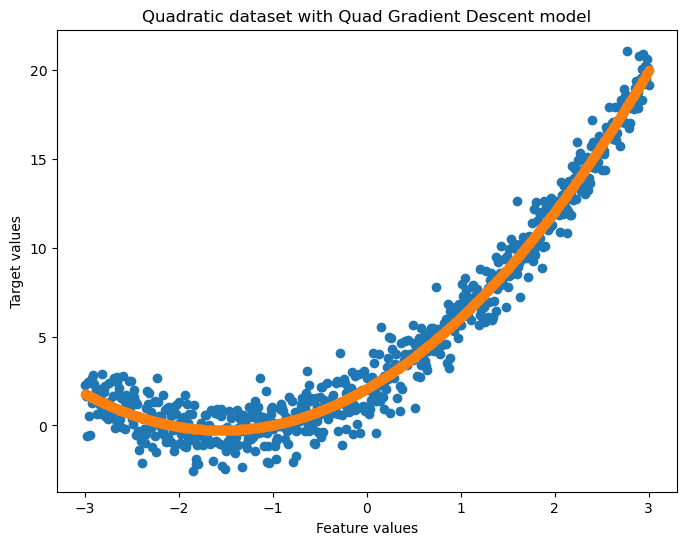

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(Xn, yn)
plt.scatter(Xn, parabgrad.predict(Xn))
plt.title("Quadratic dataset with Quad Gradient Descent model")
plt.xlabel("Feature values")
plt.ylabel("Target values")
plt.show()

#### 2.6 Обучаем модель линейной регрессии для "квадратичного" датасета

In [21]:
lineinquad = LinRegres()
linweightsanal = lineinquad.analytparam(Xn_train, yn_train)
linweightsanal

(array([[3.02537811]]), array([5.07848359]))

#### 2.6.1 Значения функции потерь на тренировочной и тестовой выборках

In [22]:
lineinquad.funcloss(Xn_train, yn_train), lineinquad.funcloss(Xn_test, yn_test)

(np.float64(7.965372791745684), np.float64(8.365622264413622))

#### 2.6.2 Визуализация построенной модели линейной регрессии на "квадратичном" датасете

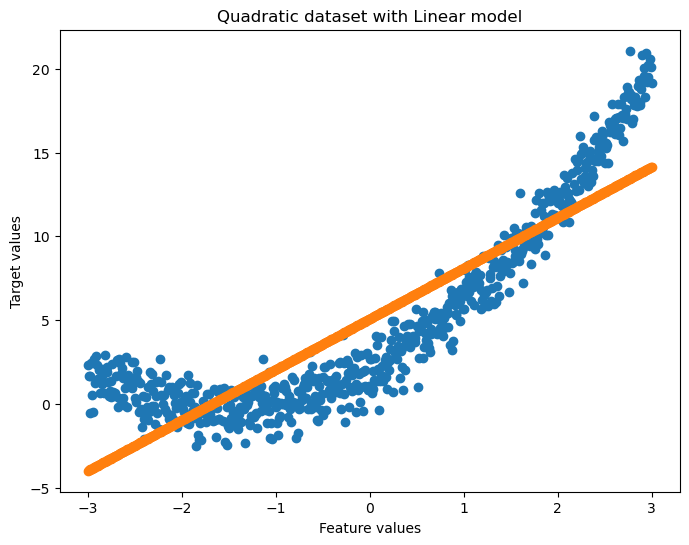

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(Xn, yn)
plt.scatter(Xn, lineinquad.predict(Xn))
plt.title("Quadratic dataset with Linear model")
plt.xlabel("Feature values")
plt.ylabel("Target values")
plt.show()

### 3. Многочлен третьей степени

### 3.1 Определяем класс Троичная регрессия с одним методом - аналитический

In [24]:
class TripleRegres:
    def init(model):
        pass
    
    def analytparam (model, X, y):
        X_f = np.hstack((np.ones([X.shape[0], 1]), X, X ** 2, X ** 3))
        model.weights = np.dot(np.dot(np.linalg.inv(np.dot(X_f.T, X_f)), X_f.T), y)
        return model.weights

    def predict(model, X):
        X_f = np.hstack((np.ones([X.shape[0], 1]), X, X ** 2, X ** 3))
        return np.vstack(np.dot(X_f, model.weights))

    def funcloss(model, X, y):
        return (np.sum((model.predict(X) - y)**2))/(X.shape[0])

#### 3.2 Обучаем троичную модель аналитическим путём

In [25]:
triplabola = TripleRegres()
tripleweights = triplabola.analytparam(Xn_train, yn_train)
tripleweights

array([[ 2.09102379e+00],
       [ 3.04582095e+00],
       [ 9.76235148e-01],
       [-2.38841496e-03]])

#### 3.2.1 Значения функции потерь на тренировочной и тестовой выборках

In [26]:
triplabola.funcloss(Xn_train, yn_train), triplabola.funcloss(Xn_test, yn_test)

(np.float64(0.9553458275123362), np.float64(1.0668950836378612))

#### 3.2.2 Визуализация построенной троичной модели аналитическим путём

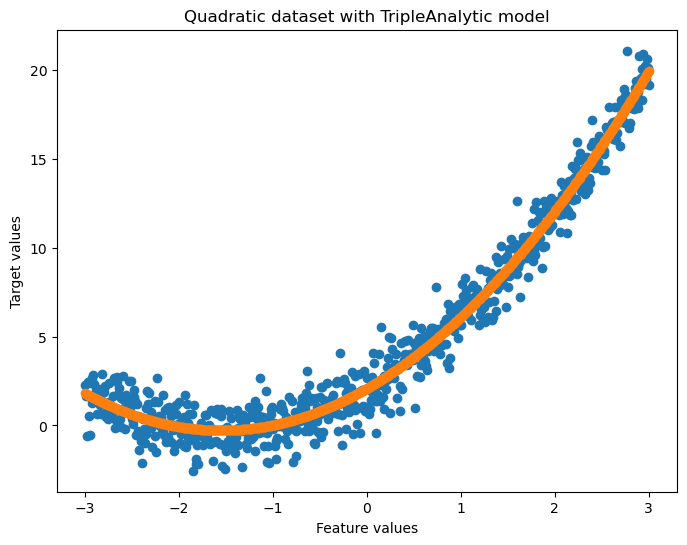

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(Xn, yn)
plt.scatter(Xn, triplabola.predict(Xn))
plt.title("Quadratic dataset with TripleAnalytic model")
plt.xlabel("Feature values")
plt.ylabel("Target values")
plt.show()